# Tutorial 2: Brain connectivity

## Requirements

To ensure reproducibility, we recommend creating a dedicated conda environment with the following specifications:

Software environment

Python ≥ 3.9

Jupyter Notebook or JupyterLab

### Dataset: 

The dataset comprises structural connectivity matrices from 161 subjects, each with a dimensionality of 20 × 20, along with associated age metadata
https://github.com/KGatica/High-Order-interactions/tree/master/dataset

<img src="lifespan.png" width="300">


## 1. Structural Connectivity Changes Across the Healthy Lifespan

In this tutorial, we will analyse changes in structural brain connectivity across the healthy lifespan using graph-theoretical measures. The analysis is performed using Python-based tools within a Jupyter Notebook environment.


In [41]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import bct 

### Data loading and visualization

In [20]:
sc_data = loadmat("sc_det_m20.mat")["sc"]
age_data = loadmat("ages_up.mat")["ages_up"]
num_subj = np.shape(age_data)[1]

print("N =",num_subj)
print(np.shape(sc_data))
print(np.shape(age_data))

N = 161
(20, 20, 161)
(1, 161)


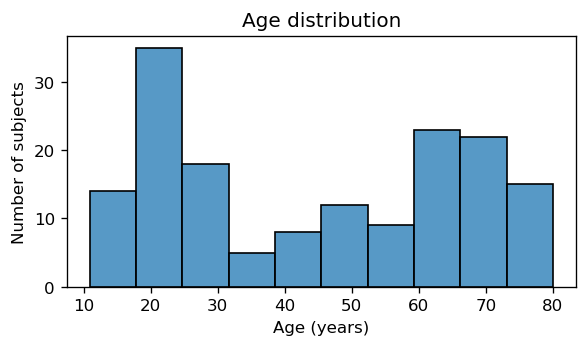

In [49]:
plt.figure(figsize=(5, 3), dpi=120)
sns.histplot(age_data.flatten(), bins=10)
plt.xlabel("Age (years)")
plt.ylabel("Number of subjects")
plt.title("Age distribution")
plt.tight_layout()
plt.show()

We will visualize average structural connectivity matrices for two age groups: younger subjects (age ≤ 20 years) and older subjects (age ≥ 60 years).

Connectivity values are normalized by the global maximum and displayed in grayscale.

In [59]:
print("sc_data_norm shape:", sc_data_norm.shape)
print("age_data shape:", age_data.shape)


sc_data_norm shape: (20, 20, 161)
age_data shape: (1, 161)


In [ ]:
sc_data_norm = sc_data/np.max(sc_data)
age_data = age_data.squeeze()                 # (161,)

# define age groups
younger_idx = age_data <= 40
older_idx   = age_data > 40

# compute mean connectivity matrices
sc_young = np.mean(sc_data_norm[:,:,younger_idx],axis=2)
sc_old   = np.mean(sc_data_norm[:,:,older_idx],axis=2)

# plot
plt.figure(figsize=(6, 3), dpi=120)

plt.subplot(121)
plt.imshow(sc_young, cmap='gray',vmin=0,vmax=1)
plt.title("Younger (≤ 20)")
plt.axis("off")

plt.subplot(122)
plt.imshow(sc_old, cmap='gray',vmin=0,vmax=1)
plt.title("Older (≥ 60)")
plt.axis("off")



(np.float64(-0.5), np.float64(19.5), np.float64(19.5), np.float64(-0.5))

### Extracting global connectome properties

Pearson r = -0.38, p = 0.000


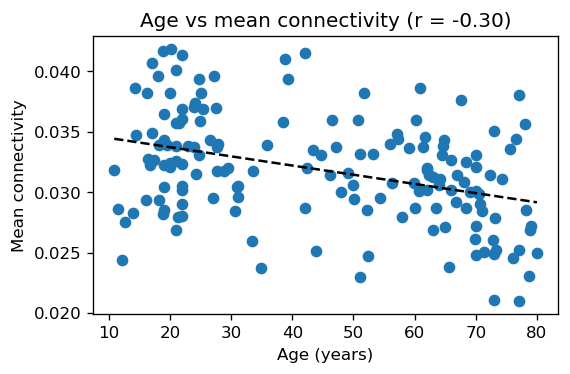

In [143]:
sc_mean_per_subject = np.mean(sc_data_norm, axis=(0, 1))

plt.figure(figsize=(5, 3), dpi=120)
plt.scatter(age_data, sc_mean_per_subject)

p = np.polyfit(age_data, sc_mean_per_subject, 1)
xfit = np.linspace(age.min(), age.max(), 100)
yfit = np.polyval(p, xfit)
plt.plot(xfit, yfit,'k--')

plt.xlabel("Age (years)")
plt.ylabel("Mean connectivity")
plt.title(f"Age vs mean connectivity (r = {r:.2f})")

r, p = pearsonr(age_data, sc_mean_per_subject)
print(f"Pearson r = {r:.2f}, p = {p:.3f}")

### Extracting topological connectome properties

<img src="bct_network.png" width="400">

<img src="bct.png" width="500">

* Mikail Rubinov, Olaf Sporns, Complex network measures of brain connectivity: Uses and interpretations, NeuroImage, https://doi.org/10.1016/j.neuroimage.2009.10.003.

In [149]:
import bct  # Brain Connectivity Toolbox

nodes = sc_data_norm.shape[0]# Number of nodes in the connectome
num_subj = sc_data_norm.shape[2]# Number of subjects

# ------------------------------------------------------------------
# Initialize arrays to store global network measures (one per subject)
# ------------------------------------------------------------------
# Segregation measure
transitivity = np.zeros((1, num_subj))  # triangle-based segregation
# Integration measure
efficiency        = np.zeros((1, num_subj))  # global efficiency

for s in range(num_subj):
    if s % 20 == 0:
        print(s)

    # Structural connectivity matrix for subject s (nodes × nodes)
    W = sc_data_norm[:, :, s]

    # -----------------------
    # Integration measure
    # -----------------------
    # Global efficiency: average efficiency of information transfer
    efficiency[0, s] = bct.efficiency_wei(W)

    # -----------------------
    # Segregation measure
    # -----------------------
    # Transitivity: global clustering coefficient based on triangles
    # High values indicate strong local segregation
    transitivity[0, s] = bct.transitivity_wu(W)


0
20
40
60
80
100
120
140
160


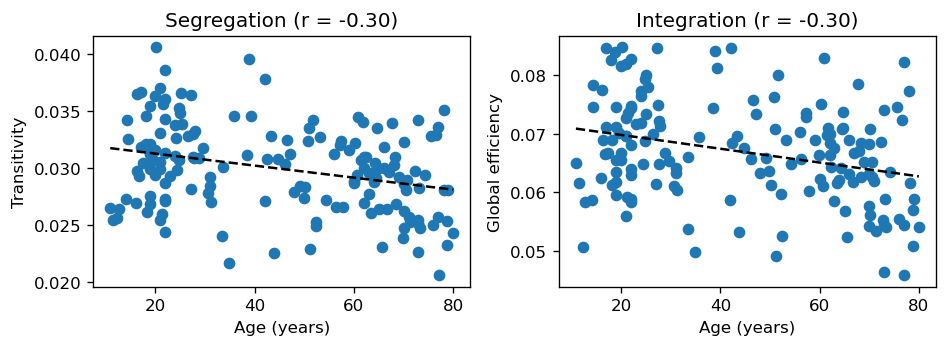

In [150]:

transitivity = transitivity_all.squeeze()
efficiency   = efficiency_all.squeeze()

metrics = [
    (transitivity, "Transitivity", "Segregation"),
    (efficiency,   "Global efficiency", "Integration"),
]

plt.figure(figsize=(8, 3), dpi=120)

for i, (y, ylabel, title) in enumerate(metrics, 1):
    r, _ = pearsonr(age, y)
    
    # linear trend
    p = np.polyfit(age, y, 1)
    xfit = np.linspace(age.min(), age.max(), 100)
    yfit = np.polyval(p, xfit)

    plt.subplot(1, 2, i)
    plt.scatter(age, y)
    plt.plot(xfit, yfit,'--k')
    plt.xlabel("Age (years)")
    plt.ylabel(ylabel)
    plt.title(f"{title} (r = {r:.2f})")

plt.tight_layout()
plt.show()


* In our analysis, older participants showed decreases in global efficiency, transitivity, and node strength, suggesting an overall weakening of structural connectivity.

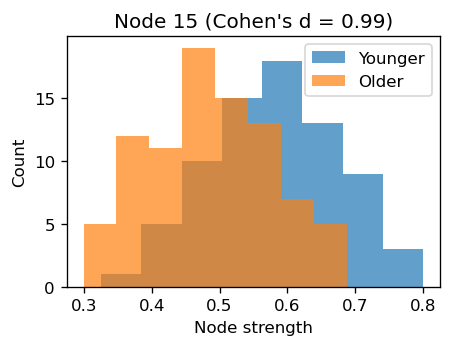

Text(0.5, 1.0, 'Effect size of age differences (node strength)')

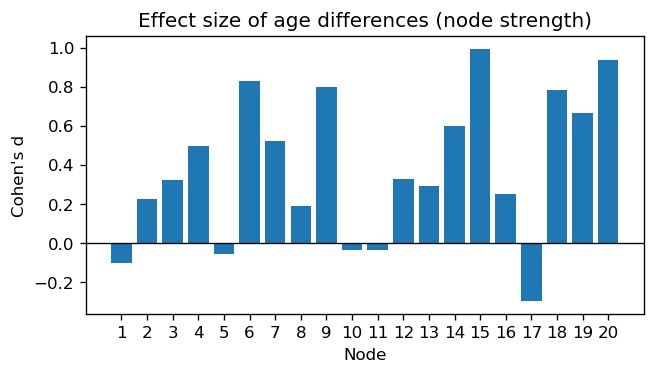

In [219]:
#Node strength per subject (nodes × subjects)
strength = np.sum(sc_data_norm, axis=1)

# Cohen's d function
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_std = np.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

# Node with largest absolute effect
n_max = 14#np.argmax(np.abs(dvals))

fig, ax = plt.subplots(figsize=(4, 3), dpi=120)

ax.hist(strength[n_max, younger_idx], bins=8, alpha=0.7, label="Younger")
ax.hist(strength[n_max, older_idx],   bins=8, alpha=0.7, label="Older")

ax.set_xlabel("Node strength")
ax.set_ylabel("Count")
ax.set_title(f"Node {n_max + 1} (Cohen's d = {dvals[n_max]:.2f})")
ax.legend()

plt.tight_layout()
plt.show()


dvals = [cohens_d(strength[n, younger_idx], strength[n, older_idx])
         for n in range(nodes)]

plt.figure(figsize=(6, 3), dpi=120)
x = np.arange(1, nodes + 1)  # labels: 1-20
plt.bar(x, dvals)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Node")
plt.xticks(np.arange(1, nodes + 1))

plt.ylabel("Cohen's d")
plt.title("Effect size of age differences (node strength)")

In [ ]:
dvals

### Brain atlas

<img src="SFMs.png" width="400">

* Brain atlas and image: Diez, I., Bonifazi, P., Escudero, I. et al. A novel brain partition highlights the modular skeleton shared by structure and function. Sci Rep 5, 10532 (2015). https://doi.org/10.1038/srep10532

## 2. Functional connectivity changes across the Healthy Lifespan


<img src="fc_slides.png" width="550">


In [166]:
fc_data = np.zeros((nodes, nodes, num_subj))

for s in range(1, num_subj):
    fname = f"./timeseries/ts_m20_p{s:03d}.txt"
    ts = np.loadtxt(fname).T              # shape: (T, 20)

    # Pearson correlation (FC)
    fc = np.corrcoef(ts, rowvar=False)

    fc_data[:, :, s - 1] = fc

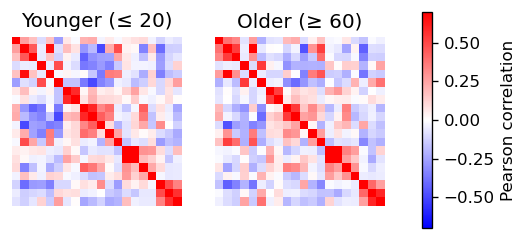

In [190]:

# Mean FC matrices by age group
fc_young = np.mean(fc_data[:, :, younger_idx], axis=2)
fc_old   = np.mean(fc_data[:, :, older_idx], axis=2)

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(4, 3), dpi=120)

im1 = axes[0].imshow(fc_young, vmin=-0.7, vmax=0.7, cmap="bwr")
axes[0].set_title("Younger (≤ 20)")
axes[0].axis("off")

im2 = axes[1].imshow(fc_old, vmin=-0.7, vmax=0.7, cmap="bwr")
axes[1].set_title("Older (≥ 60)")
axes[1].axis("off")

# Shared colorbar
cax = fig.add_axes([0.98, 0.2, 0.02, 0.6])  
# [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label("Pearson correlation")

plt.show()


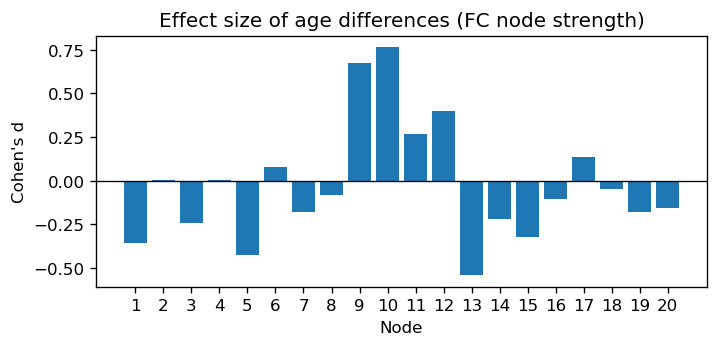

In [220]:

# FC node strength per subject (nodes × subjects)
strength_fc = np.sum(np.abs(fc_data), axis=1)

# Effect size per node
dvals_fc = [cohens_d(strength_fc[n, younger_idx], strength_fc[n, older_idx])
         for n in range(nodes)]

# -------------------------
# Effect size barplot
# -------------------------
plt.figure(figsize=(6, 3), dpi=120)
x = np.arange(1, nodes + 1)  # Etiquetas del 1 al 20
plt.bar(x, dvals_fc)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Node")
plt.xticks(np.arange(1, nodes + 1))
plt.ylabel("Cohen's d")
plt.title("Effect size of age differences (FC node strength)")
plt.tight_layout()
plt.show()


## 3. Linking structure and function

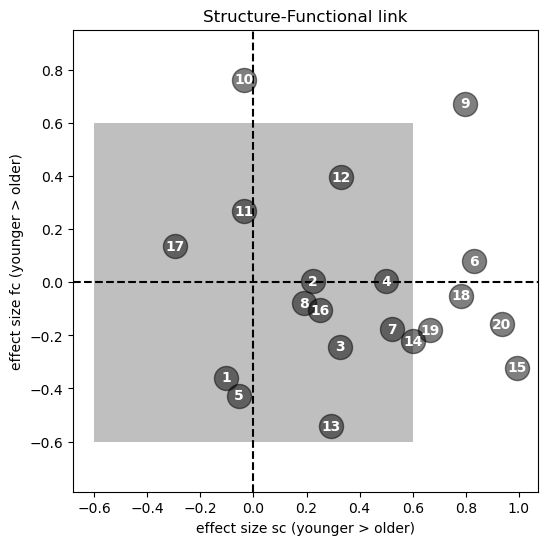

In [241]:
from matplotlib.patches import Rectangle

n_points = 20
indices = np.arange(1, n_points + 1)
tau = 0.6

# Generate colors and set point size
colors = plt.cm.viridis((indices - 1) / (n_points - 1))
size = 300

plt.figure(figsize=(6, 6))
ax = plt.gca()  # Get current axis

# Add shaded central area
highlight_rect = Rectangle(
    (-tau, -tau), 1.2, 1.2,
    facecolor='grey', alpha=0.5, zorder=0
)
ax.add_patch(highlight_rect)

# Scatter plot
plt.scatter(dvals, dvals_fc, c='k', s=size, edgecolors='k', alpha=0.5)

# Label each point with its index
for i in range(n_points):
    plt.text(dvals[i], dvals_fc[i], str(indices[i]),
             color='white', fontsize=10,
             ha='center', va='center', weight='bold')

# Reference lines
plt.axhline(0, color='k', linestyle='--')
plt.axvline(0, color='k', linestyle='--')

# Axis labels and title
plt.xlabel('effect size sc (younger > older)')
plt.ylabel('effect size fc (younger > older)')
plt.title('Structure-Functional link')
# plt.grid(True)
plt.axis('equal')
plt.show()
